   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.0/93.0 kB 2.3 MB/s eta 0:00:00


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


EXPERIMENT 13
Advanced Policy Optimization using PPO, TRPO and DDPG

Environment: Pendulum-v1
Training Timesteps: 10000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


PPO Completed


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


TRPO Completed
DDPG Completed


FULL TRAINING DATASET


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Episode,PPO_Reward,TRPO_Reward,DDPG_Reward
0,1,-1187.130154,-1187.130154,-1329.731471
1,2,-1353.012270,-1422.615034,-1645.138594
2,3,-1295.815303,-1335.627029,-1566.445552
3,4,-1074.759396,-1171.456551,-1520.966057
4,5,-1367.817580,-1530.832106,-1541.540030
5,6,-904.834894,-1045.341381,-1371.971950
6,7,-913.346383,-818.517819,-1285.060369
7,8,-904.291199,-1068.398464,-1172.889733
8,9,-1054.814138,-856.264026,-984.825658
9,10,-1309.769820,-1472.643772,-1049.663330


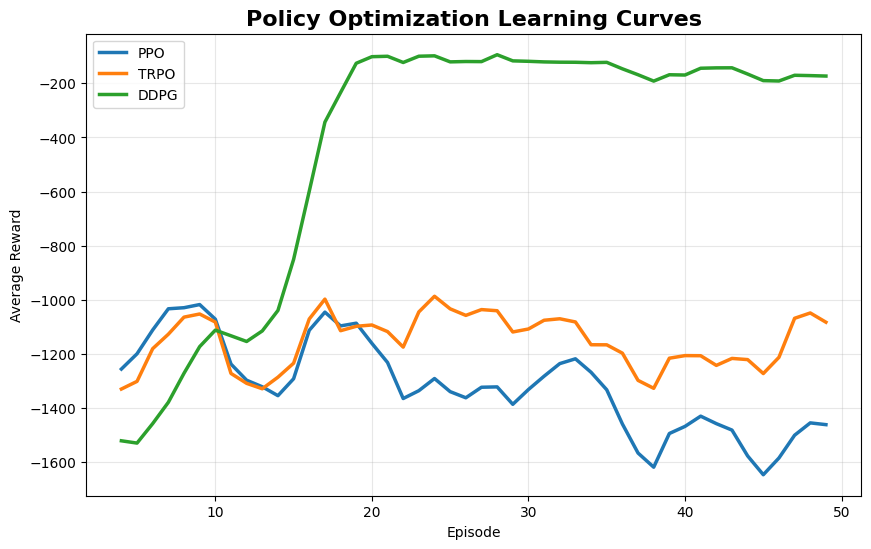

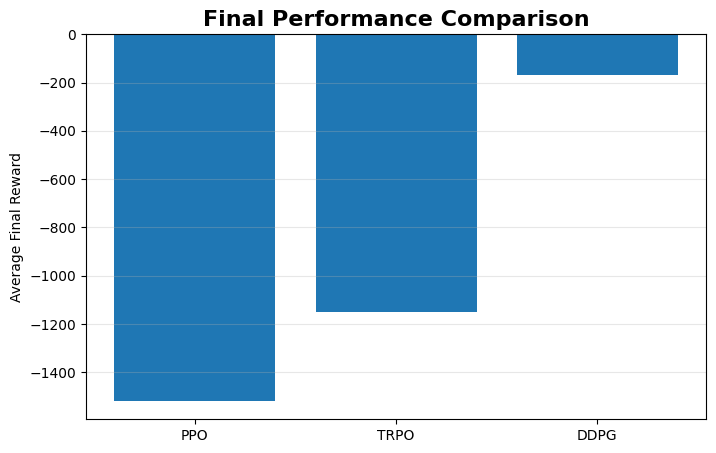

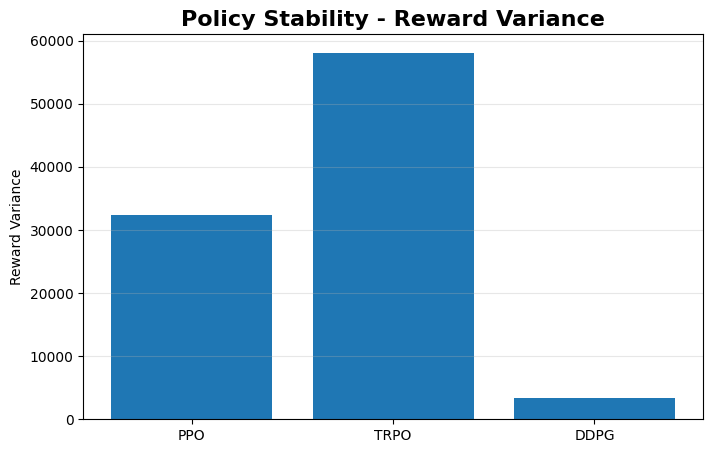

/tmp/ipykernel_1335/989898148.py:255: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


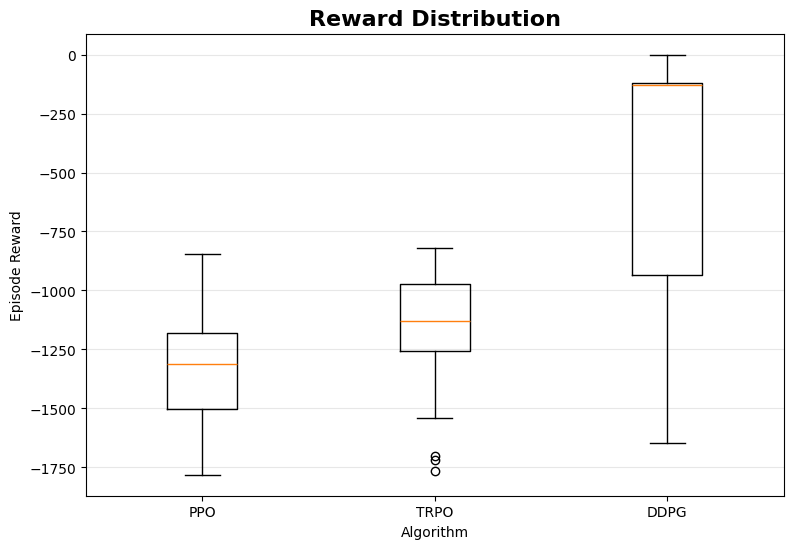

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


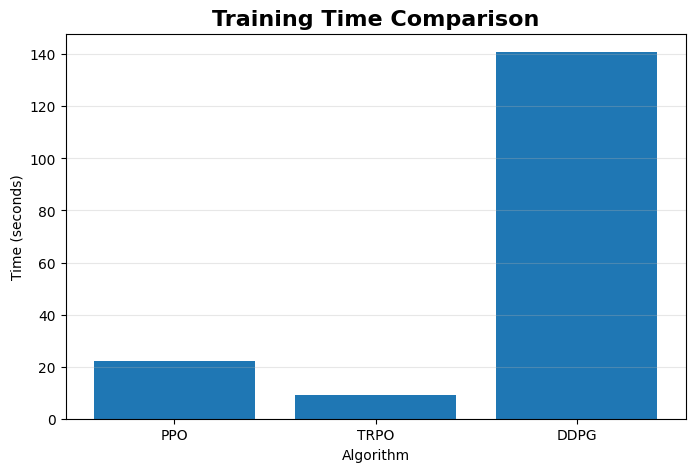

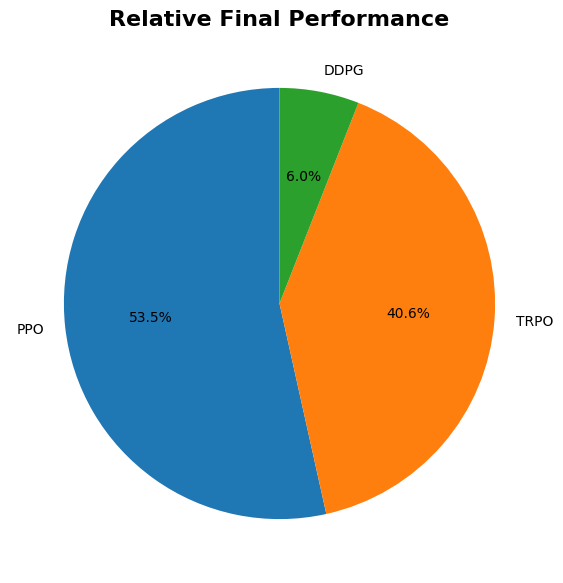



SUMMARY TABLE


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Algorithm,Final Average Reward,Maximum Reward,Variance,Stability,Training Time
0,PPO,-1518.88,-847.43,32363.04,0.0055,22.07
1,TRPO,-1151.66,-818.52,58100.27,0.0041,9.18
2,DDPG,-169.37,-0.72,3379.30,0.0169,140.87




FINAL RESULTS
Best Final Reward: DDPG
Most Stable: DDPG
Lowest Variance: DDPG
Fastest Training: TRPO


CONCLUSION
PPO, TRPO and DDPG were successfully evaluated
using the Pendulum-v1 continuous-control environment.
PPO uses clipped policy updates to provide stable
policy optimization.
TRPO constrains policy updates using a trust region.
DDPG uses an actor-critic approach for continuous actions.
The algorithms were compared using reward,
variance, stability, reward distribution and
training time.

Generated Files:
PPO_TRPO_DDPG_Full_Dataset.csv
PPO_TRPO_DDPG_Summary.csv

Experiment 13 Completed Successfully.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
!pip -q install stable-baselines3 sb3-contrib gymnasium

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import time
from stable_baselines3 import PPO, DDPG
from sb3_contrib import TRPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.noise import NormalActionNoise

np.random.seed(42)

print("="*75)
print("EXPERIMENT 13")
print("Advanced Policy Optimization using PPO, TRPO and DDPG")
print("="*75)

ENV_NAME="Pendulum-v1"
TIMESTEPS=10000

class RewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.rewards=[]
        self.steps=[]

    def _on_step(self):
        infos=self.locals.get("infos",[])
        dones=self.locals.get("dones",[])

        for info,done in zip(infos,dones):
            if done and "episode" in info:
                self.rewards.append(
                    float(info["episode"]["r"])
                )
                self.steps.append(
                    self.num_timesteps
                )
        return True

def make_env():
    return Monitor(gym.make(ENV_NAME))

print("\nEnvironment:",ENV_NAME)
print("Training Timesteps:",TIMESTEPS)

ppo_env=make_env()
ppo_callback=RewardCallback()

start=time.time()

ppo=PPO(
    "MlpPolicy",
    ppo_env,
    learning_rate=0.0003,
    n_steps=256,
    batch_size=64,
    gamma=0.99,
    verbose=0,
    seed=42
)

ppo.learn(
    total_timesteps=TIMESTEPS,
    callback=ppo_callback
)

ppo_time=time.time()-start
ppo_env.close()

print("PPO Completed")

trpo_env=make_env()
trpo_callback=RewardCallback()

start=time.time()

trpo=TRPO(
    "MlpPolicy",
    trpo_env,
    learning_rate=0.0003,
    gamma=0.99,
    verbose=0,
    seed=42
)

trpo.learn(
    total_timesteps=TIMESTEPS,
    callback=trpo_callback
)

trpo_time=time.time()-start
trpo_env.close()

print("TRPO Completed")

ddpg_env=make_env()
ddpg_callback=RewardCallback()

action_noise=NormalActionNoise(
    mean=np.zeros(1),
    sigma=0.1*np.ones(1)
)

start=time.time()

ddpg=DDPG(
    "MlpPolicy",
    ddpg_env,
    learning_rate=0.001,
    buffer_size=10000,
    batch_size=64,
    gamma=0.99,
    action_noise=action_noise,
    verbose=0,
    seed=42
)

ddpg.learn(
    total_timesteps=TIMESTEPS,
    callback=ddpg_callback
)

ddpg_time=time.time()-start
ddpg_env.close()

print("DDPG Completed")

ppo_rewards=ppo_callback.rewards
trpo_rewards=trpo_callback.rewards
ddpg_rewards=ddpg_callback.rewards

min_len=min(
    len(ppo_rewards),
    len(trpo_rewards),
    len(ddpg_rewards)
)

ppo_rewards=ppo_rewards[:min_len]
trpo_rewards=trpo_rewards[:min_len]
ddpg_rewards=ddpg_rewards[:min_len]

dataset=pd.DataFrame({
    "Episode":range(1,min_len+1),
    "PPO_Reward":ppo_rewards,
    "TRPO_Reward":trpo_rewards,
    "DDPG_Reward":ddpg_rewards
})

print("\n")
print("="*75)
print("FULL TRAINING DATASET")
print("="*75)

display(dataset)

dataset.to_csv(
    "PPO_TRPO_DDPG_Full_Dataset.csv",
    index=False
)

window=5

ppo_smooth=dataset["PPO_Reward"].rolling(window).mean()
trpo_smooth=dataset["TRPO_Reward"].rolling(window).mean()
ddpg_smooth=dataset["DDPG_Reward"].rolling(window).mean()

plt.figure(figsize=(10,6))

plt.plot(
    ppo_smooth,
    label="PPO",
    linewidth=2.5
)

plt.plot(
    trpo_smooth,
    label="TRPO",
    linewidth=2.5
)

plt.plot(
    ddpg_smooth,
    label="DDPG",
    linewidth=2.5
)

plt.title(
    "Policy Optimization Learning Curves",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

final_ppo=np.mean(ppo_rewards[-10:])
final_trpo=np.mean(trpo_rewards[-10:])
final_ddpg=np.mean(ddpg_rewards[-10:])

plt.figure(figsize=(8,5))

plt.bar(
    ["PPO","TRPO","DDPG"],
    [final_ppo,final_trpo,final_ddpg]
)

plt.title(
    "Final Performance Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Average Final Reward")
plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

ppo_var=np.var(ppo_rewards[-10:])
trpo_var=np.var(trpo_rewards[-10:])
ddpg_var=np.var(ddpg_rewards[-10:])

plt.figure(figsize=(8,5))

plt.bar(
    ["PPO","TRPO","DDPG"],
    [ppo_var,trpo_var,ddpg_var]
)

plt.title(
    "Policy Stability - Reward Variance",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Reward Variance")
plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

plt.figure(figsize=(9,6))

plt.boxplot(
    [
        ppo_rewards,
        trpo_rewards,
        ddpg_rewards
    ],
    labels=[
        "PPO",
        "TRPO",
        "DDPG"
    ]
)

plt.title(
    "Reward Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Algorithm")
plt.ylabel("Episode Reward")
plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

training_times=[
    ppo_time,
    trpo_time,
    ddpg_time
]

plt.figure(figsize=(8,5))

plt.bar(
    ["PPO","TRPO","DDPG"],
    training_times
)

plt.title(
    "Training Time Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Algorithm")
plt.ylabel("Time (seconds)")
plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

best_rewards=[
    max(ppo_rewards),
    max(trpo_rewards),
    max(ddpg_rewards)
]

plt.figure(figsize=(7,7))

plt.pie(
    [
        abs(final_ppo),
        abs(final_trpo),
        abs(final_ddpg)
    ],
    labels=[
        "PPO",
        "TRPO",
        "DDPG"
    ],
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Relative Final Performance",
    fontsize=16,
    fontweight="bold"
)

plt.show()

ppo_stability=1/(1+np.std(ppo_rewards[-10:]))
trpo_stability=1/(1+np.std(trpo_rewards[-10:]))
ddpg_stability=1/(1+np.std(ddpg_rewards[-10:]))

comparison=pd.DataFrame({
    "Algorithm":[
        "PPO",
        "TRPO",
        "DDPG"
    ],
    "Final Average Reward":[
        round(final_ppo,2),
        round(final_trpo,2),
        round(final_ddpg,2)
    ],
    "Maximum Reward":[
        round(max(ppo_rewards),2),
        round(max(trpo_rewards),2),
        round(max(ddpg_rewards),2)
    ],
    "Variance":[
        round(ppo_var,2),
        round(trpo_var,2),
        round(ddpg_var,2)
    ],
    "Stability":[
        round(ppo_stability,4),
        round(trpo_stability,4),
        round(ddpg_stability,4)
    ],
    "Training Time":[
        round(ppo_time,2),
        round(trpo_time,2),
        round(ddpg_time,2)
    ]
})

print("\n")
print("="*75)
print("SUMMARY TABLE")
print("="*75)

display(comparison)

comparison.to_csv(
    "PPO_TRPO_DDPG_Summary.csv",
    index=False
)

best_algorithm=comparison.loc[
    comparison["Final Average Reward"].idxmax(),
    "Algorithm"
]

stable_algorithm=comparison.loc[
    comparison["Stability"].idxmax(),
    "Algorithm"
]

fast_algorithm=comparison.loc[
    comparison["Training Time"].idxmin(),
    "Algorithm"
]

lowest_variance=comparison.loc[
    comparison["Variance"].idxmin(),
    "Algorithm"
]

print("\n")
print("="*75)
print("FINAL RESULTS")
print("="*75)

print(
    "Best Final Reward:",
    best_algorithm
)

print(
    "Most Stable:",
    stable_algorithm
)

print(
    "Lowest Variance:",
    lowest_variance
)

print(
    "Fastest Training:",
    fast_algorithm
)

print("\n")
print("="*75)
print("CONCLUSION")
print("="*75)

print(
    "PPO, TRPO and DDPG were successfully evaluated"
)

print(
    "using the Pendulum-v1 continuous-control environment."
)

print(
    "PPO uses clipped policy updates to provide stable"
)

print(
    "policy optimization."
)

print(
    "TRPO constrains policy updates using a trust region."
)

print(
    "DDPG uses an actor-critic approach for continuous actions."
)

print(
    "The algorithms were compared using reward,"
)

print(
    "variance, stability, reward distribution and"
)

print(
    "training time."
)

print("\nGenerated Files:")
print("PPO_TRPO_DDPG_Full_Dataset.csv")
print("PPO_TRPO_DDPG_Summary.csv")

print("\nExperiment 13 Completed Successfully.")